### Analisis Exploratorio de datos de las Visualizaciones - Movie_Insights

#### Set de datos: TMDB Movies 2020-2025


Este notebook documenta el analisis de los resultados mostrados por los graficos creados para el set de datos de peliculas.

Importación de las librerias necesarias para realizar el analisis.


En la siguiente línea de código se importan todos los metodos de los graficos de la clase Visualizador desde el archivo de código Clase visualizador del paquete visualizacion. También se importa las librerías pandas y matplotlib

In [19]:
from scr.visualizacion.ClaseVisualizador import *
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px



Ya que la visualicacion de los resultados de los graficos depende de lo realizado en la ClaseProcesadorEDA la llamamos y realizamos las instancias requerias para su buen funcionamiento

In [7]:
from scr.eda.ClaseProcesadorEDA import *
import pandas as pd

In [8]:
ruta = "../data/raw/tmdb_2020_to_2025.csv"
cargador = CargadorDatos(ruta)
df_original = cargador.cargar_csv()

procesador = ProcesadorEDA(df_original)

Ya que se puede apreciar en el documento previo, no tomaremos en cuenta los metodos info_basica, tip_dato, con_nulos y muestra y pasaremos directo a la limpieza del data set

In [9]:
df_limpio = procesador.limpieza_datos()
print("Los datos han sido limpiados exitosamente")
print(df_limpio)

Limpieza completa
Los datos han sido limpiados exitosamente
      Unnamed: 0  adult                     backdrop_path    genre_ids  \
0              0  False  /hpXBJxLD2SEf8l2CspmSeiHrBKX.jpg   18, 27, 14   
1              1  False  /d6HIjhk2f8BiZnVQ43gUv67khmX.jpg    10749, 18   
2              2  False  /82lM4GJ9uuNvNDOEpxFy77uv4Ak.jpg  28, 878, 12   
3              3  False  /6zKjoOOb3OZnZuiHtQZn4Kd69Gq.jpg       27, 53   
4              4  False  /vZK3f5N8Fv2LcyFYLwt6dz0HE1H.jpg       28, 35   
...          ...    ...                               ...          ...   
9994        9994  False  /aBmy0ofVWJ45AeBh7F5XWROi1c2.jpg       28, 12   
9995        9995  False  /yDjAzBtNxAG6RxDR9SWLnGFM0I7.jpg           18   
9996        9996  False  /tMT3tsh7lXJTkHq4Gjq1XkNkgOr.jpg       18, 35   
9997        9997  False                               NaN           18   
9998        9998  False  /9G3G0KelkB7PuFOXZXykK3ylTcq.jpg           27   

           id original_language                    

Utilizamos para algunos graficos los metodos Resumen estadistico y Matriz de correlacion es por esto que los cargamos


In [10]:
#Muestra el resumen de estadistico
print("\nResumen estadistico")

display(procesador.resumen_estadistico())

#Muestra la matriz de correlacion
print("\nMatriz de correlacion")
display(procesador.matriz_correlacion())


Resumen estadistico


,Unnamed: 0,id,popularity,vote_average,vote_count
count,9999.000000,9.999000e+03,9999.000000,9999.000000,9999.000000
mean,4999.000000,9.797428e+05,5.814750,4.551764,221.900790
std,2886.607005,2.630966e+05,13.101449,2.968713,879.465244
min,0.000000,5.492000e+03,0.192900,0.000000,0.000000
25%,2499.500000,7.845155e+05,3.673650,0.000000,0.000000
50%,4999.000000,9.500850e+05,4.320600,5.708000,6.000000
75%,7498.500000,1.175968e+06,5.650550,6.724000,61.000000
max,9998.000000,1.576287e+06,951.346000,10.000000,21265.000000



Matriz de correlacion


,Unnamed: 0,popularity,vote_average,vote_count
Unnamed: 0,1.000000,-0.581166,-0.380915,-0.524579
popularity,-0.581166,1.000000,0.012181,0.074892
vote_average,-0.380915,0.012181,1.000000,0.368547
vote_count,-0.524579,0.074892,0.368547,1.000000


Ejecucion de los graficos y analisis de los resultados

Histograma para apreciar cual es la cantidad peliculas con mayor promedio de voto

In [ ]:
#Histograma
viz = Visualizador(df_limpio)
histo = viz.histograma_Prom_votos()
plt.show()

Scatter que muestra la relacion que existe entre la popularidad y el promedio de votos que tienen las peliculas

Esta importacion de plotly.io es para mostrar el grafico en la web y no limitar la interacividad

In [15]:
import plotly.io as pio
pio.renderers.default = "browser"

In [ ]:
#Dispersión
scatte = viz.scatter_popularidad()
scatte.show()

Heatmap que muestra las correlaciones que existen entre cada columna del set de datos


In [35]:
#Mapa correlacion
proc = ProcesadorEDA(df_limpio)
matriz_c = proc.matriz_correlacion()

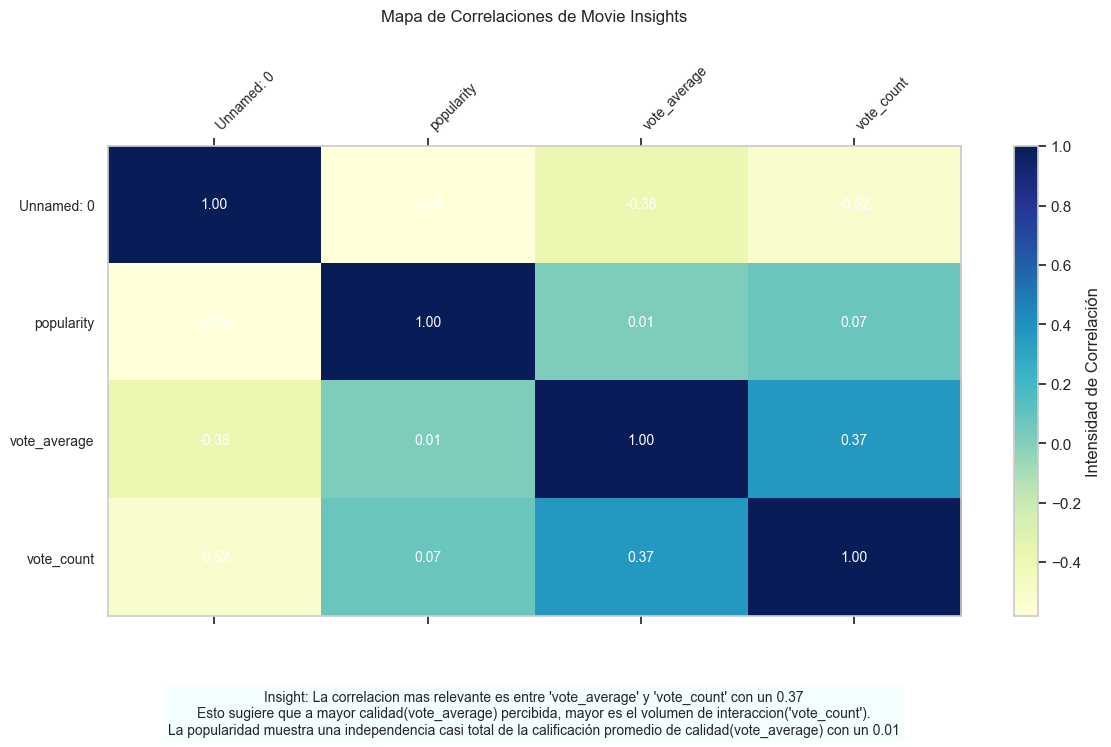

In [36]:
#Mapa correlacion
proc = ProcesadorEDA(df_limpio)
matriz_c = proc.matriz_correlacion()

heat_map = viz.heatmap_correlacion(matriz_c)
plt.show()

Grafico de barras verticales que muestran el analisis comparatorio del promedio, minimo y maximo del resumen estadistico realizado en la ClaseProcesadorEDA

In [30]:
resumen = proc.resumen_estadistico()
print("\nColumnas disponibles para analizar:", resumen.columns.tolist())


Columnas disponibles para analizar: ['Unnamed: 0', 'id', 'popularity', 'vote_average', 'vote_count']


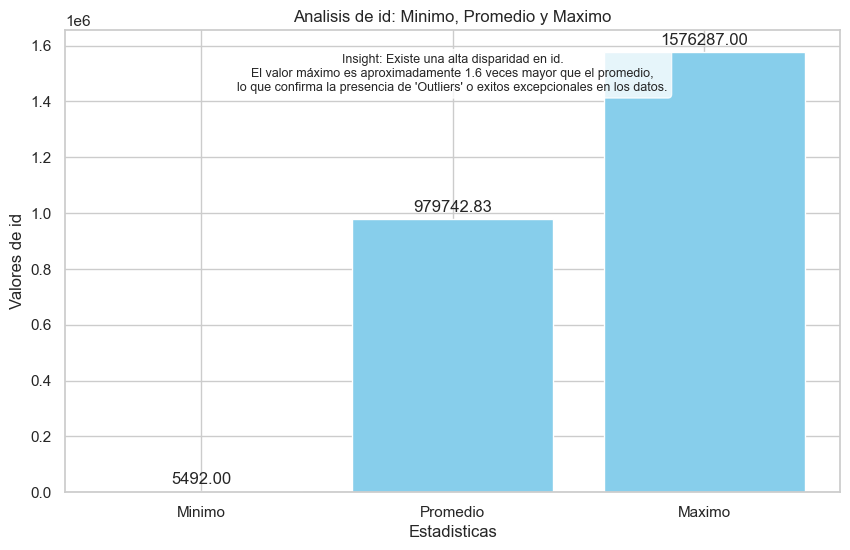

In [31]:

col_selecci = input("Escriba el nombre de la columna que desea graficar: ").strip()
if col_selecci in resumen.columns:
    fig_est = viz.barras_estadis(resumen, col_selecci)
    plt.show()
else:
    print(f"Error: La columna '{col_selecci}' no se encuentra en el dataset.")




Grafico de barras verticales que muestra la tendencia en los idiomas presentes en el dataset

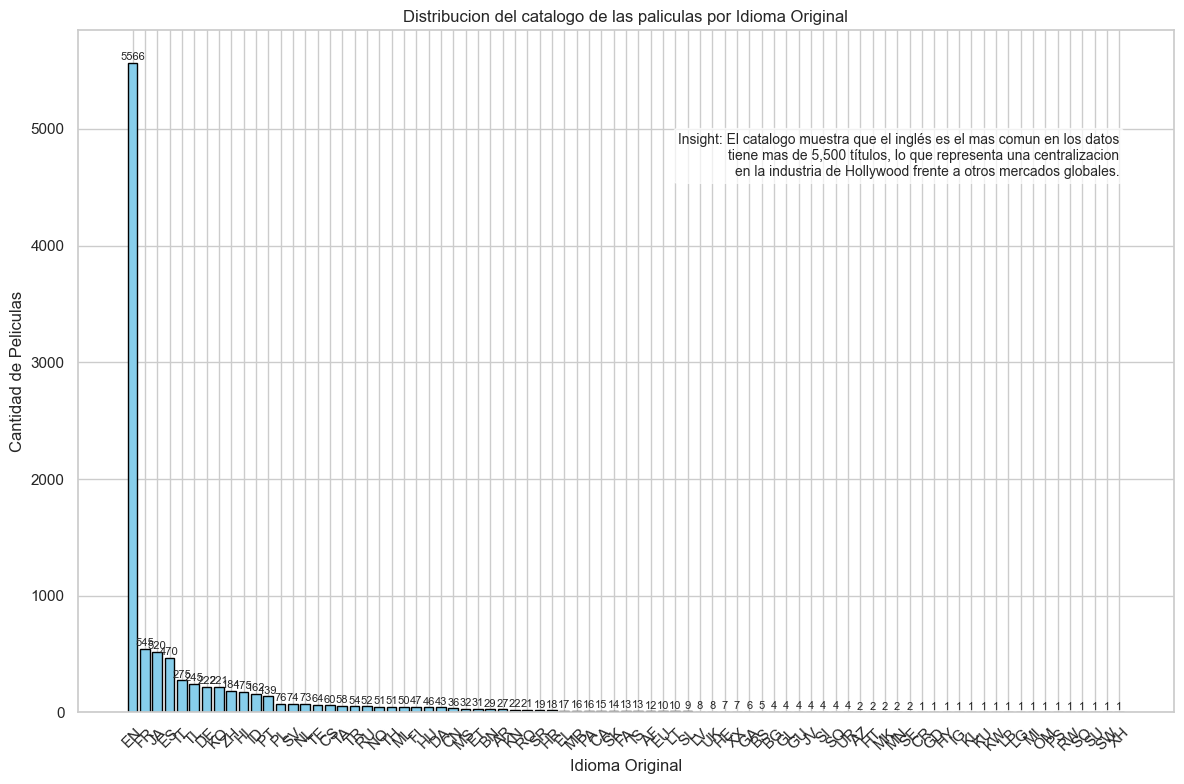

In [25]:
#barras idiomas

bar_idiomas = viz.barras_idiomas()
plt.show()

Grafico de barras horizontales que muestra las 10 peliculas mas votadas dentro del set de datos

In [33]:
#barras horizontales
top_votos = viz.barrash_top10_votos()
top_votos.show()


Grafico lineal que muestra la tendencia historica de la popularidad

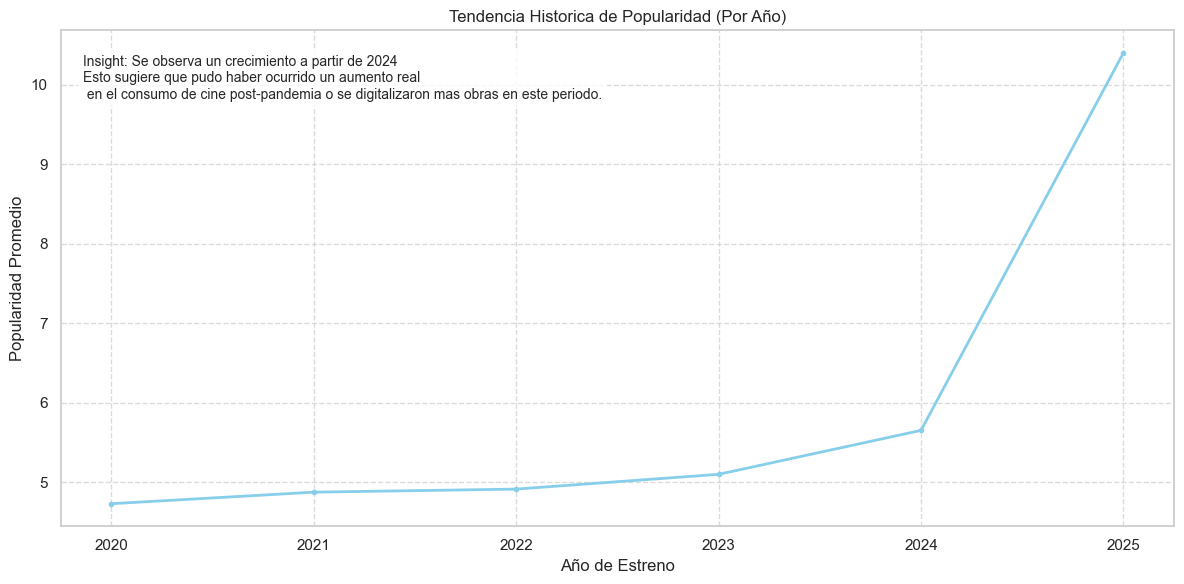

In [27]:
# grafico lineal
evo_fechas = viz.lineal_evolucion_anual()
plt.show()

Grafico de barras horizontales que muestra la pelicula mas popular y su año de lanzamiento

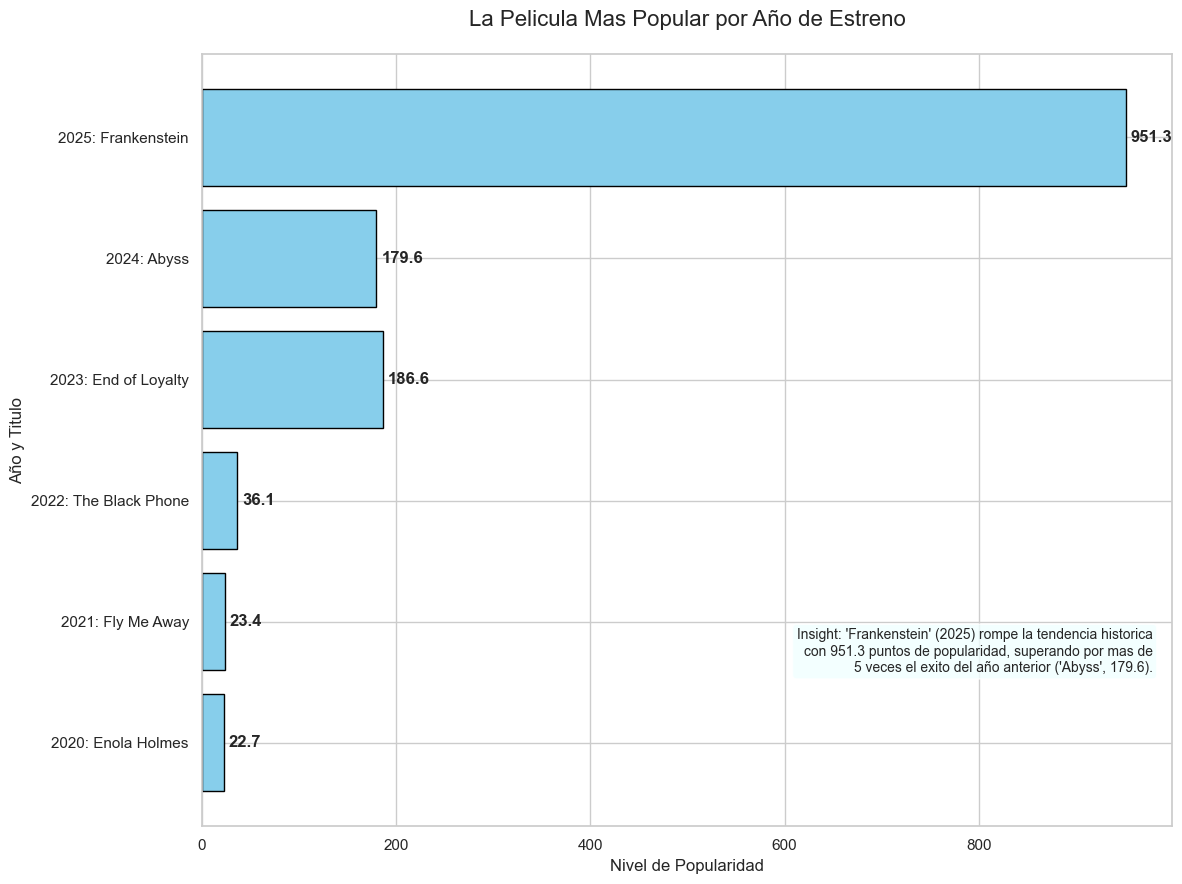

In [26]:
# barras top anunal
bar_top_anual = viz.barras_pelicula_por_ano()
plt.show()